## Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### Loading the Dataset

In [2]:
df = pd.read_csv('./data/fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
unique_values_count = df['FraudFound_P'].value_counts()
print(unique_values_count)

FraudFound_P
0    14497
1      923
Name: count, dtype: int64


In [4]:
df_fraud = df[df['FraudFound_P'] == 1]

### Visualize Fraud Percentage by Columns

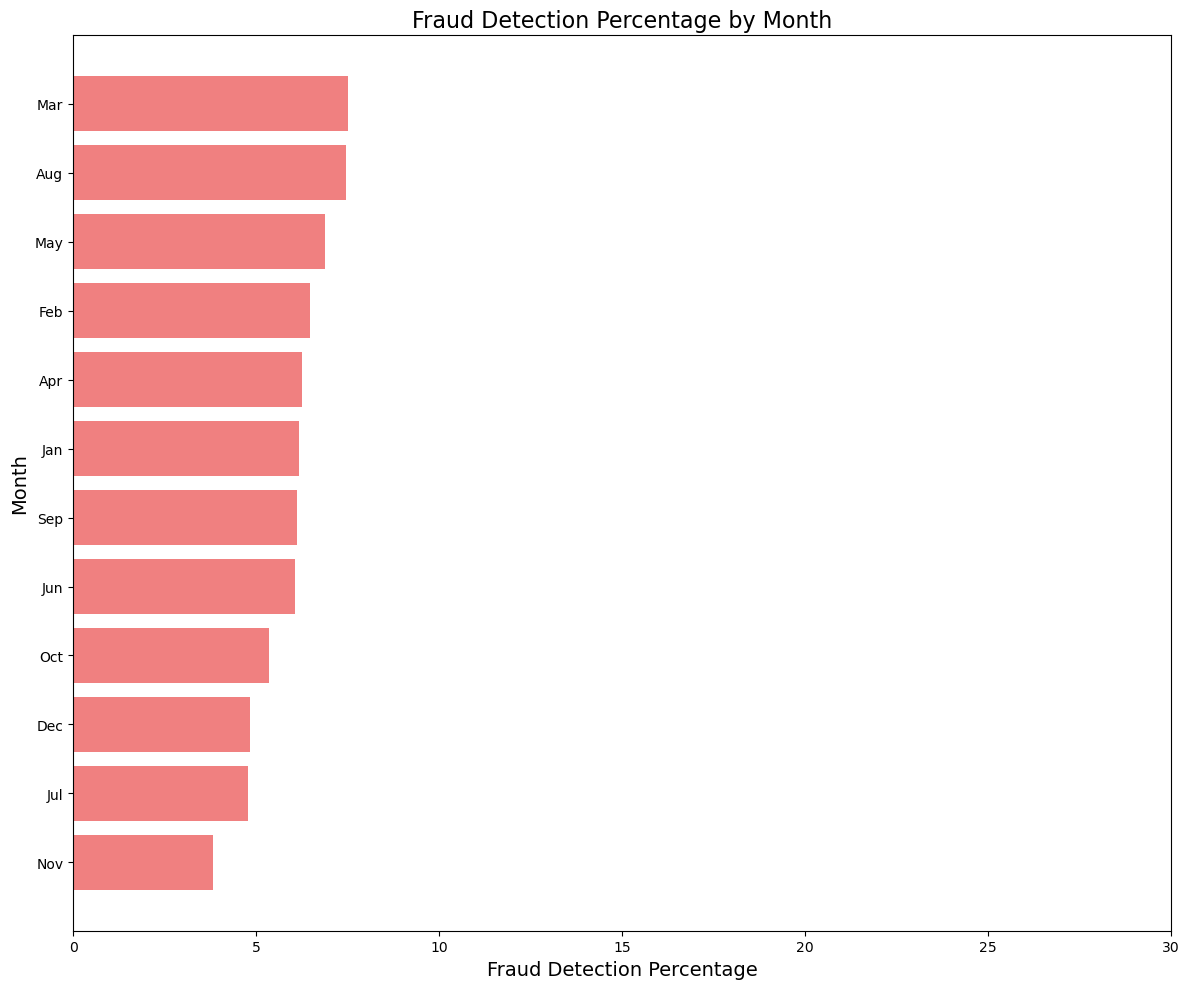

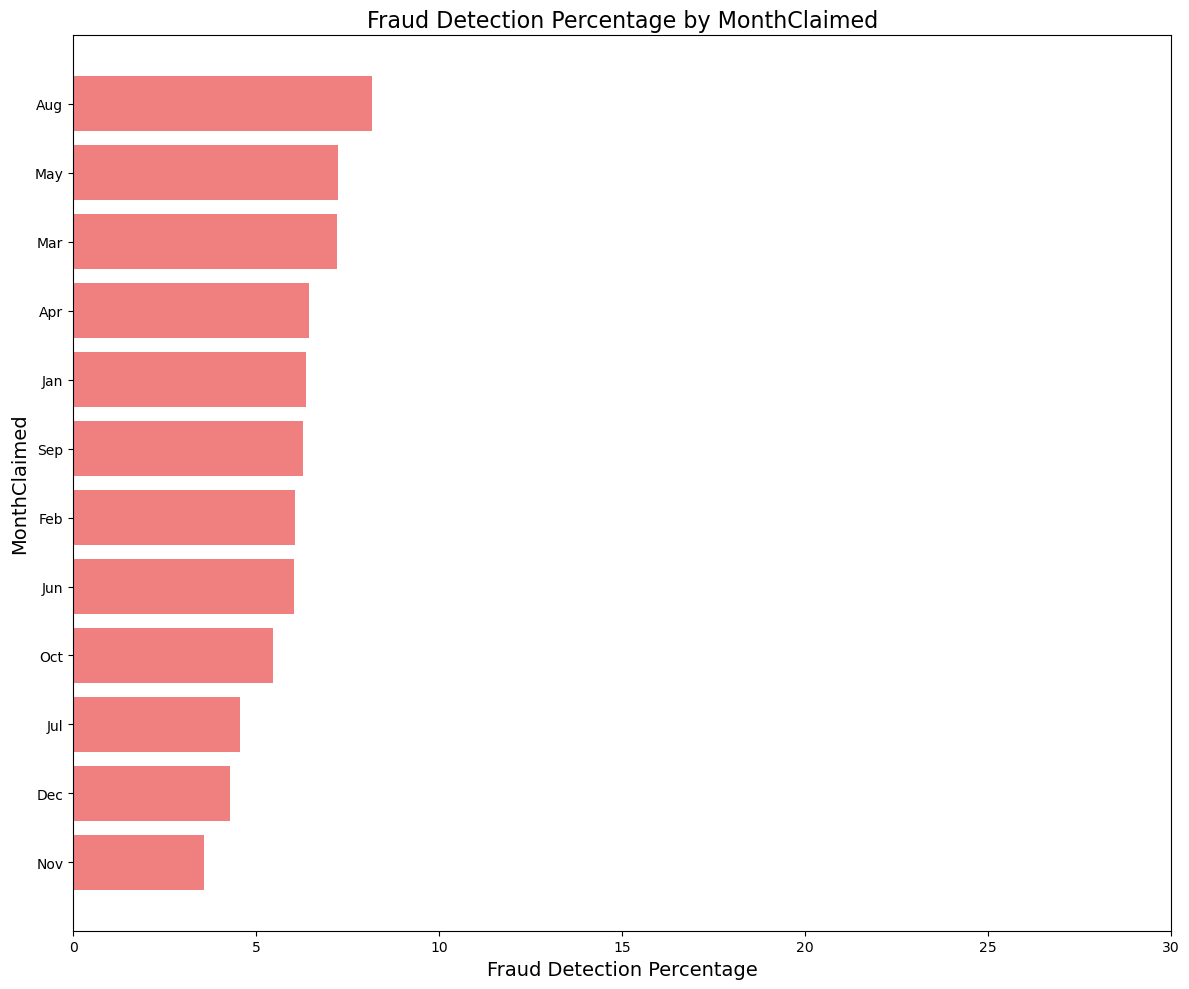

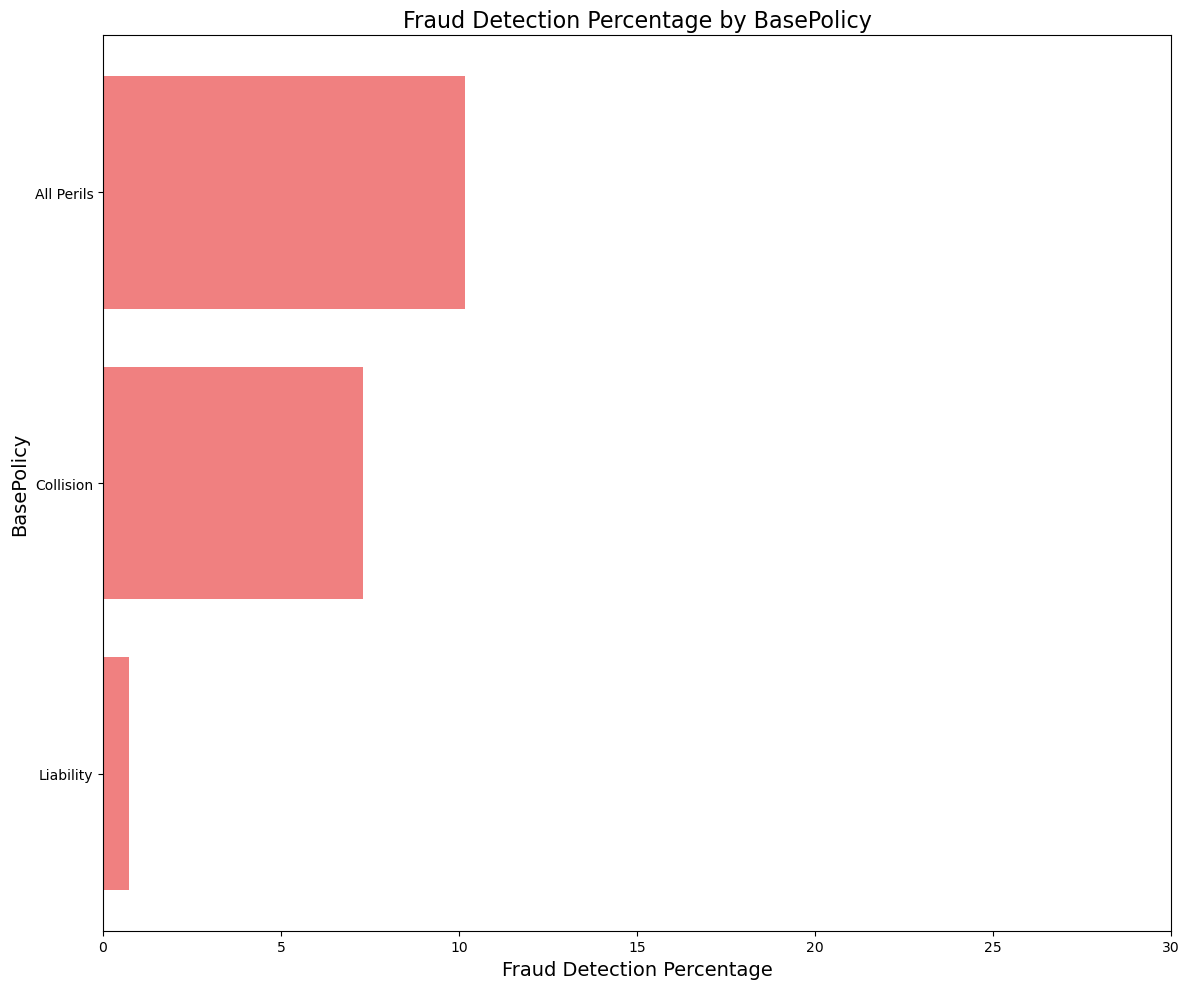

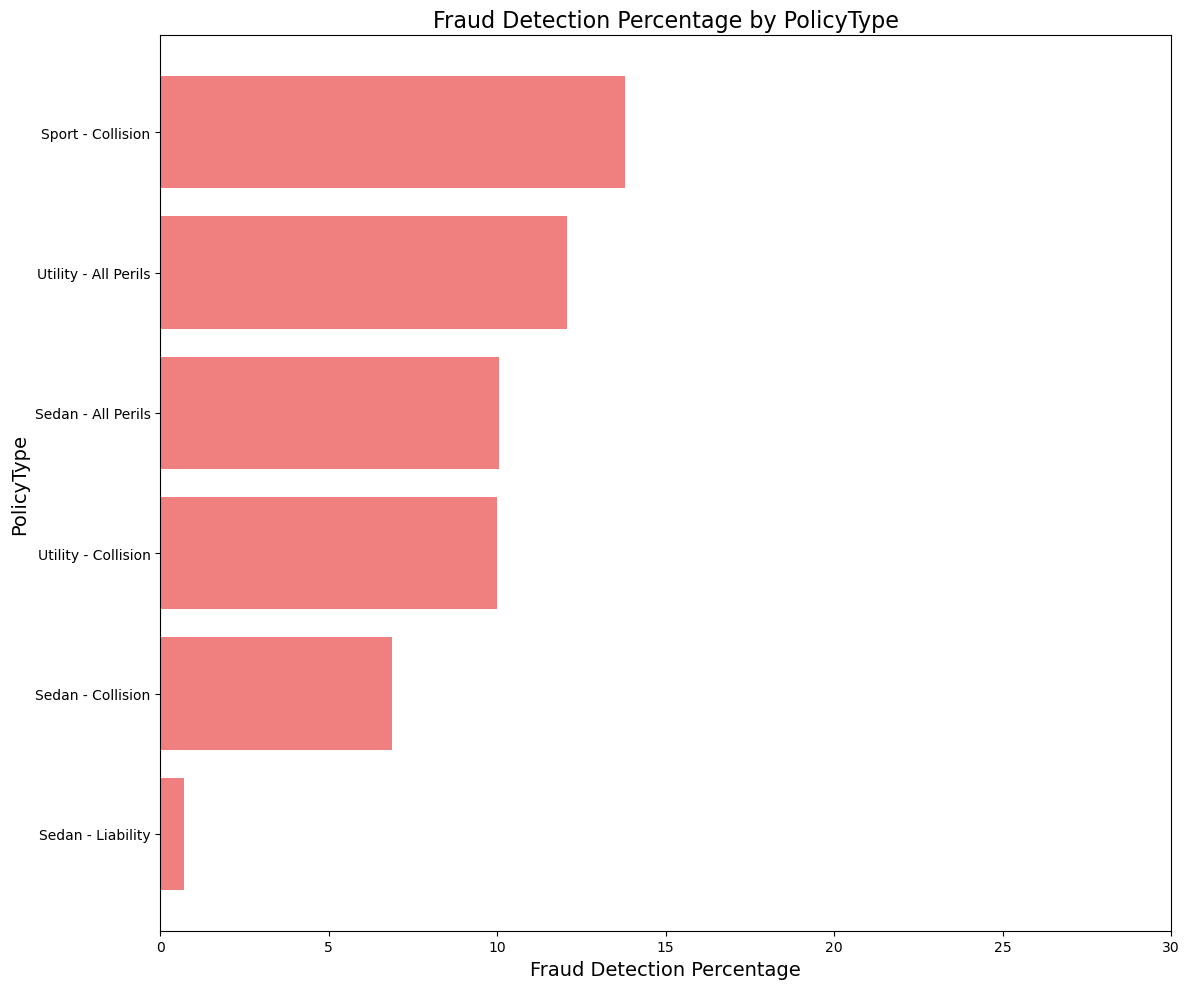

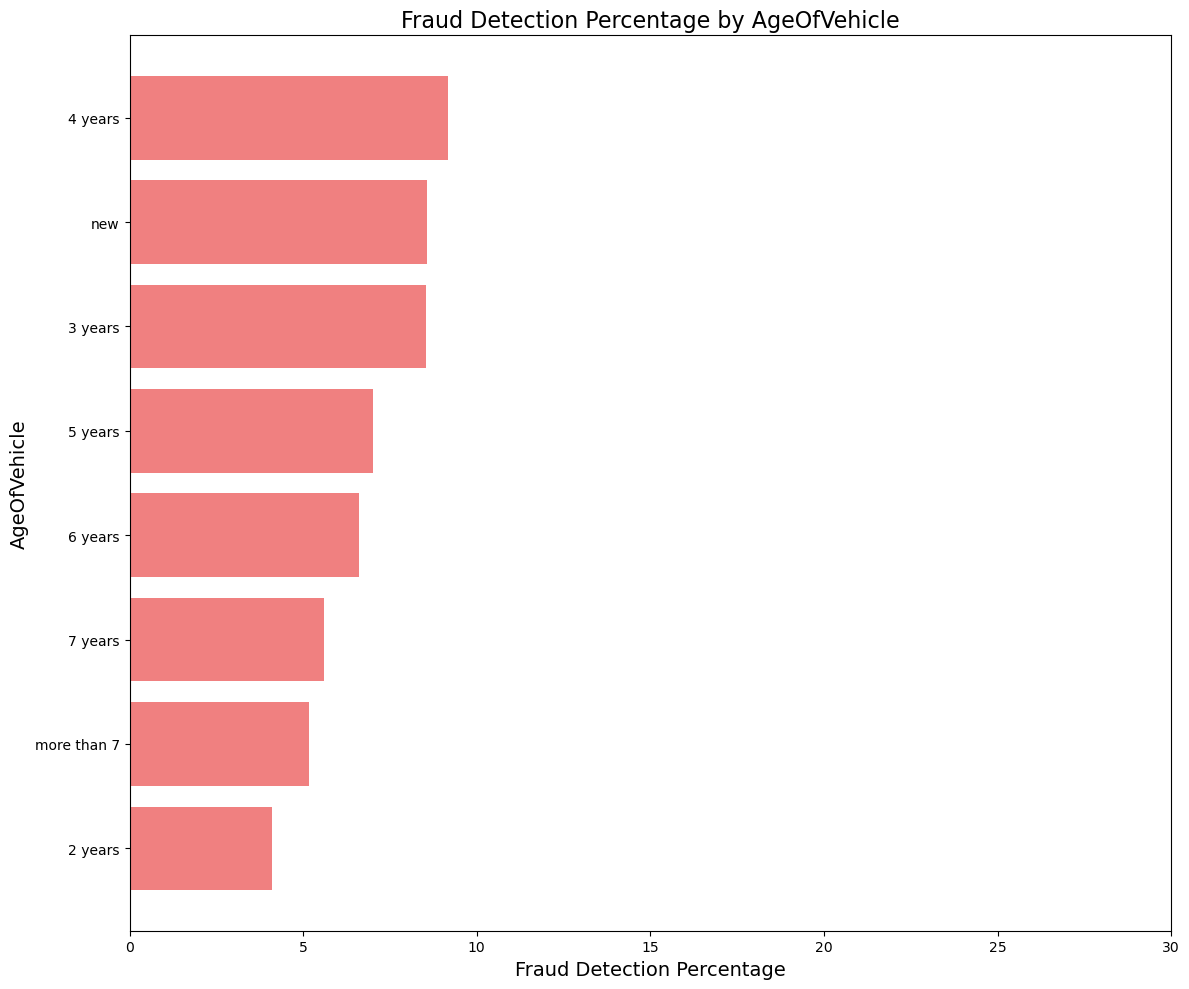

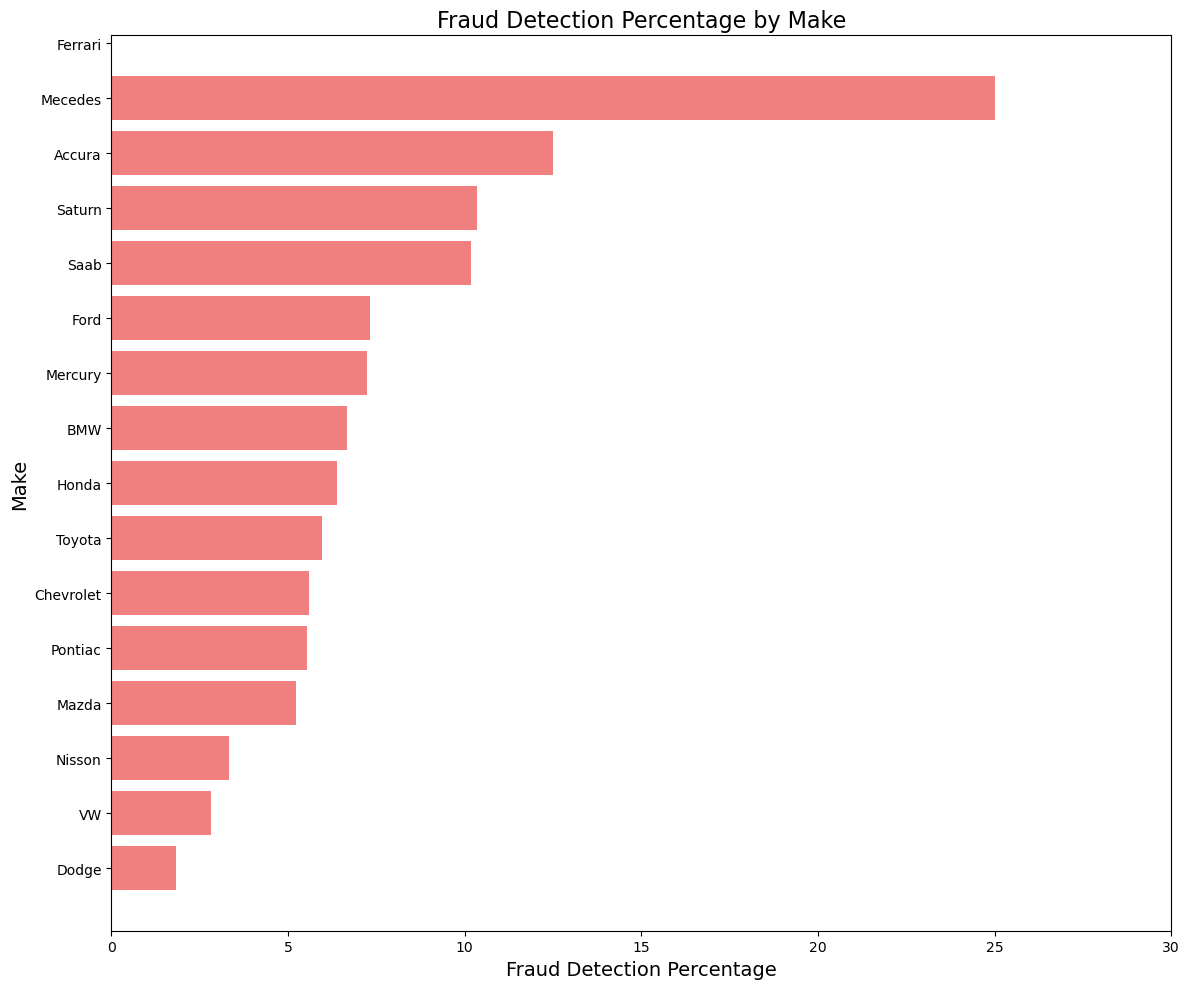

In [5]:
def plot_fraud_percentage_by_column(df, column_name):
    df_counts = df[column_name].value_counts()
    df_fraud_counts = df[df['FraudFound_P'] == 1][column_name].value_counts()
    df_fraud_percentage = (df_fraud_counts / df_counts) * 100
    df_fraud_percentage = pd.DataFrame(df_fraud_percentage).reset_index()
    df_fraud_percentage.columns = [column_name, 'Fraud %']
    df_fraud_percentage = df_fraud_percentage.sort_values(by=['Fraud %'])
    
    plt.figure(figsize=(12, 10))
    plt.barh(df_fraud_percentage[column_name], df_fraud_percentage['Fraud %'], color='lightcoral')
    plt.xlabel('Fraud Detection Percentage', fontsize=14)
    plt.ylabel(f'{column_name}', fontsize=14)
    plt.title(f'Fraud Detection Percentage by {column_name}', fontsize=16)
    plt.xlim(0, 30)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

columns_to_plot = ['Month', 'MonthClaimed', 'BasePolicy', 'PolicyType', 'AgeOfVehicle', 'Make']

for column in columns_to_plot:
    plot_fraud_percentage_by_column(df, column)


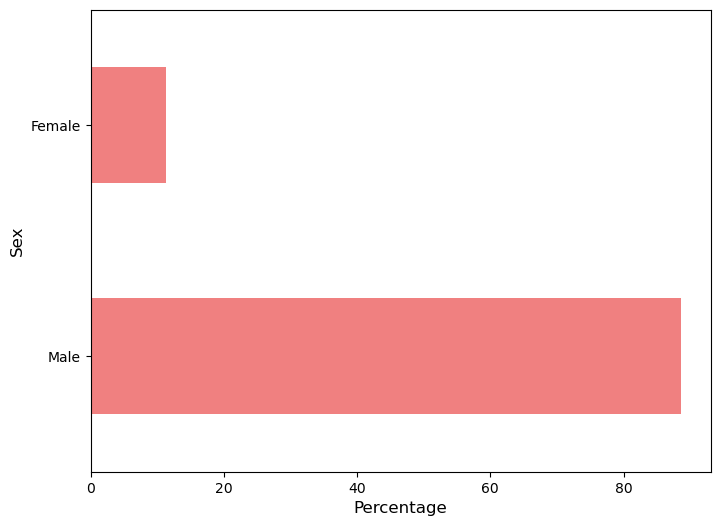

In [6]:
sex_percentage = df_fraud['Sex'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sex_percentage.plot(kind='barh', color='lightcoral')
plt.xlabel('Percentage', fontsize=12)
plt.ylabel('Sex', fontsize=12)
plt.show()
